# Exercise 1C

## 0. Library Imports

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import pprint as pp
import math
import numpy as np

## 1. Original Text

In [2]:
menu_items = {
    1:"Eggs Benedict",
    2:"Creamy Hot Porridge",
    3:"A Full Traditional English Breakfast",
    4:"Delicate English Pancakes",
    5:"Eggs Royale",
    6:"Eggs and Soldiers",
    7:"Gourmet Bacon and Egg Butty"
}

In [3]:
df = pd.DataFrame(list(menu_items.items()), columns=["Doc Number","Text"])
df.style.hide(axis="index")

Doc Number,Text
1,Eggs Benedict
2,Creamy Hot Porridge
3,A Full Traditional English Breakfast
4,Delicate English Pancakes
5,Eggs Royale
6,Eggs and Soldiers
7,Gourmet Bacon and Egg Butty


## 2. Preprocessing

### 2.1 Stemming (Manual)
1. Lowercaps
2. Removing stopwords
3. Depluralise

In [4]:
menu_items = {
    1:"egg benedict",
    2:"creamy hot porridge",
    3:"full traditional english breakfast",
    4:"delicate english pancake",
    5:"egg royale",
    6:"egg soldier",
    7:"gourmet bacon egg butty"
}

In [5]:
df = pd.DataFrame(list(menu_items.items()), columns=["Doc Number","Texts"])
df.style.hide(axis="index")

Doc Number,Texts
1,egg benedict
2,creamy hot porridge
3,full traditional english breakfast
4,delicate english pancake
5,egg royale
6,egg soldier
7,gourmet bacon egg butty


## 3. Term-Document Matrix

In [6]:
vectorizer = CountVectorizer()

tdm = vectorizer.fit_transform(df["Texts"])

In [7]:
tdm_df = pd.DataFrame(
    tdm.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=df["Doc Number"]
)

tdm_df = tdm_df.T
display(tdm_df)

Doc Number,1,2,3,4,5,6,7
bacon,0,0,0,0,0,0,1
benedict,1,0,0,0,0,0,0
breakfast,0,0,1,0,0,0,0
butty,0,0,0,0,0,0,1
creamy,0,1,0,0,0,0,0
delicate,0,0,0,1,0,0,0
egg,1,0,0,0,1,1,1
english,0,0,1,1,0,0,0
full,0,0,1,0,0,0,0
gourmet,0,0,0,0,0,0,1


### 4. Inverted Index

In [8]:
inverted_index = {}

for term in tdm_df.index:
    postings = []

    for doc_id in tdm_df.columns:
        freq = tdm_df.loc[term, doc_id]

        if freq > 0:
            postings.append((doc_id, freq))

    inverted_index[term] = postings

In [9]:
inverted_index = {
    term: [(doc_id, int(freq)) for doc_id, freq in postings]
    for term, postings in inverted_index.items()
}
pp.pprint(inverted_index)

{'bacon': [(7, 1)],
 'benedict': [(1, 1)],
 'breakfast': [(3, 1)],
 'butty': [(7, 1)],
 'creamy': [(2, 1)],
 'delicate': [(4, 1)],
 'egg': [(1, 1), (5, 1), (6, 1), (7, 1)],
 'english': [(3, 1), (4, 1)],
 'full': [(3, 1)],
 'gourmet': [(7, 1)],
 'hot': [(2, 1)],
 'pancake': [(4, 1)],
 'porridge': [(2, 1)],
 'royale': [(5, 1)],
 'soldier': [(6, 1)],
 'traditional': [(3, 1)]}


## 5. Tf.idf

### 5.1 Normalised Term Frequency (TF)

In [10]:
doc_lengths = {i+1: len(text.lower().split()) for i, text in enumerate(df["Texts"])}
norm_tf = {}

for term, postings in inverted_index.items():
    norm_tf[term] = []

    for doc_id, tf in postings:
        norm_value = tf / doc_lengths[doc_id]
        norm_tf[term].append((doc_id, norm_value))

pp.pprint(norm_tf)

{'bacon': [(7, 0.25)],
 'benedict': [(1, 0.5)],
 'breakfast': [(3, 0.25)],
 'butty': [(7, 0.25)],
 'creamy': [(2, 0.3333333333333333)],
 'delicate': [(4, 0.3333333333333333)],
 'egg': [(1, 0.5), (5, 0.5), (6, 0.5), (7, 0.25)],
 'english': [(3, 0.25), (4, 0.3333333333333333)],
 'full': [(3, 0.25)],
 'gourmet': [(7, 0.25)],
 'hot': [(2, 0.3333333333333333)],
 'pancake': [(4, 0.3333333333333333)],
 'porridge': [(2, 0.3333333333333333)],
 'royale': [(5, 0.5)],
 'soldier': [(6, 0.5)],
 'traditional': [(3, 0.25)]}


### 5.2 Inverted Document Frequency

In [11]:
N = len(df)

Ni = {
    term: len(postings)
    for term, postings in inverted_index.items()
}

idf = {
    term: math.log(N / Ni[term])
    for term in Ni
}
pp.pprint(idf)

{'bacon': 1.9459101490553132,
 'benedict': 1.9459101490553132,
 'breakfast': 1.9459101490553132,
 'butty': 1.9459101490553132,
 'creamy': 1.9459101490553132,
 'delicate': 1.9459101490553132,
 'egg': 0.5596157879354227,
 'english': 1.252762968495368,
 'full': 1.9459101490553132,
 'gourmet': 1.9459101490553132,
 'hot': 1.9459101490553132,
 'pancake': 1.9459101490553132,
 'porridge': 1.9459101490553132,
 'royale': 1.9459101490553132,
 'soldier': 1.9459101490553132,
 'traditional': 1.9459101490553132}


### 5.3 Tf.idf

In [12]:
tf_idf = {}

for term, postings in norm_tf.items():
    tf_idf[term] = []

    for doc_id, tf_value in postings:
        score = tf_value * idf[term]
        tf_idf[term].append((doc_id, score))

pp.pprint(tf_idf)

{'bacon': [(7, 0.4864775372638283)],
 'benedict': [(1, 0.9729550745276566)],
 'breakfast': [(3, 0.4864775372638283)],
 'butty': [(7, 0.4864775372638283)],
 'creamy': [(2, 0.648636716351771)],
 'delicate': [(4, 0.648636716351771)],
 'egg': [(1, 0.27980789396771133),
         (5, 0.27980789396771133),
         (6, 0.27980789396771133),
         (7, 0.13990394698385566)],
 'english': [(3, 0.313190742123842), (4, 0.41758765616512267)],
 'full': [(3, 0.4864775372638283)],
 'gourmet': [(7, 0.4864775372638283)],
 'hot': [(2, 0.648636716351771)],
 'pancake': [(4, 0.648636716351771)],
 'porridge': [(2, 0.648636716351771)],
 'royale': [(5, 0.9729550745276566)],
 'soldier': [(6, 0.9729550745276566)],
 'traditional': [(3, 0.4864775372638283)]}


## 6. VSM Search

In [13]:
def cosine_similarity(q, r):
    # 1. dot product (only shared terms matter)
    dot = sum(q[t] * r.get(t, 0) for t in q)

    # 2. magnitude of query
    q_mag = math.sqrt(sum(v*v for v in q.values()))

    # 3. magnitude of document
    r_mag = math.sqrt(sum(v*v for v in r.values()))

    # avoid division by zero
    if q_mag == 0 or r_mag == 0:
        return 0

    return dot / (q_mag * r_mag)

In [14]:
def calculate_tf(term,doc):
    term_count = 0
    doc_length = len(doc.split())
    for word in doc.split():
        if word == term:
            term_count+=1
    return term_count/doc_length
    
def build_query_vector(query,idf):
    query_vector = {}
    for term in query.split():
        query_vector[term] = calculate_tf(term,query)

    for term in query_vector.keys():
        if term in idf.keys():
            query_vector[term] = query_vector[term] * idf[term]
        else:
            query_vector[term] = query_vector[term] * 0
    return query_vector

def build_reference_vector(reference,tf_idf):
    reference_vector = {}
    for term in reference.split():
        reference_vector[term] = calculate_tf(term,reference)
    
    for term in reference_vector.keys():
        if term in idf.keys():
            reference_vector[term] = reference_vector[term] * idf[term]
        else:
            reference_vector[term] = reference_vector[term] * 0
    return reference_vector

In [15]:
reference_vectors = {}

for doc_id,doc_texts in zip(df['Doc Number'],df['Texts']):
    reference_vectors[doc_id] = build_reference_vector(doc_texts,tf_idf)

pp.pprint(reference_vectors)

{1: {'benedict': 0.9729550745276566, 'egg': 0.27980789396771133},
 2: {'creamy': 0.648636716351771,
     'hot': 0.648636716351771,
     'porridge': 0.648636716351771},
 3: {'breakfast': 0.4864775372638283,
     'english': 0.313190742123842,
     'full': 0.4864775372638283,
     'traditional': 0.4864775372638283},
 4: {'delicate': 0.648636716351771,
     'english': 0.41758765616512267,
     'pancake': 0.648636716351771},
 5: {'egg': 0.27980789396771133, 'royale': 0.9729550745276566},
 6: {'egg': 0.27980789396771133, 'soldier': 0.9729550745276566},
 7: {'bacon': 0.4864775372638283,
     'butty': 0.4864775372638283,
     'egg': 0.13990394698385566,
     'gourmet': 0.4864775372638283}}


In [21]:
query = "porridge dish"
query_vector = build_query_vector(query,idf)

pp.pprint(query_vector)

{'dish': 0.0, 'porridge': 0.9729550745276566}


In [22]:
cosine_similarity_dict = {}
for doc_id,reference_vector in reference_vectors.items():
    cosine_similarity_dict[doc_id] = cosine_similarity(query_vector,reference_vector)

ranked = sorted(cosine_similarity_dict.items(), key=lambda x: x[1], reverse=True)
pp.pprint(ranked)


[(2, 0.5773502691896258),
 (1, 0.0),
 (3, 0.0),
 (4, 0.0),
 (5, 0.0),
 (6, 0.0),
 (7, 0.0)]


## 7. Graphs

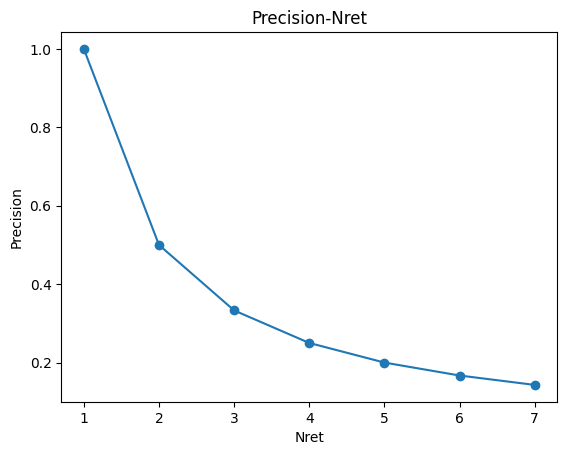

In [29]:
import matplotlib.pyplot as plt
nret=[1,2,3,4,5,6,7]

prec_1 = [1, 0.5, 0.333, 0.25, 0.2, 0.167, 0.143]
recall_1 = [1, 1, 1, 1, 1, 1, 1]

prec_2 = [1, 1, 1, 1, 1, 0.83, 0.714]
recall_2 = [0.2, 0.4, 0.6, 0.8, 1, 1, 1]

prec_3 = [1, 0.5, 0.333, 0.25, 0.2, 0.167, 0.143]
recall_3 = [1, 1, 1, 1, 1, 1, 1]

plt.plot(nret, prec_1, marker='o')
plt.xlabel("Nret")
plt.ylabel("Precision")
plt.title("Precision-Nret")
plt.show()

In [36]:
avg_prec = [(p1 + p2 + p3) / 3 for p1, p2, p3 in zip(prec_1, prec_2, prec_3)]
avg_recall = [(r1 + r2 + r3) / 3 for r1, r2, r3 in zip(recall_1, recall_2, recall_3)]

print(avg_prec)
print(avg_recall)

[1.0, 0.6666666666666666, 0.5553333333333333, 0.5, 0.4666666666666666, 0.38799999999999996, 0.3333333333333333]
[0.7333333333333334, 0.7999999999999999, 0.8666666666666667, 0.9333333333333332, 1.0, 1.0, 1.0]


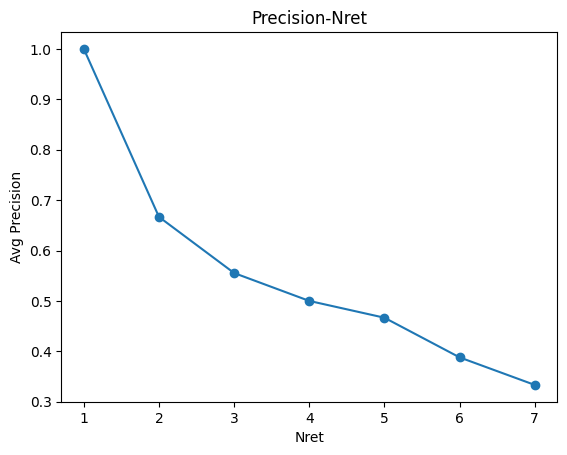

In [35]:
plt.plot(nret, avg_prec, marker='o')
plt.xlabel("Nret")
plt.ylabel("Avg Precision")
plt.title("Precision-Nret")
plt.show()

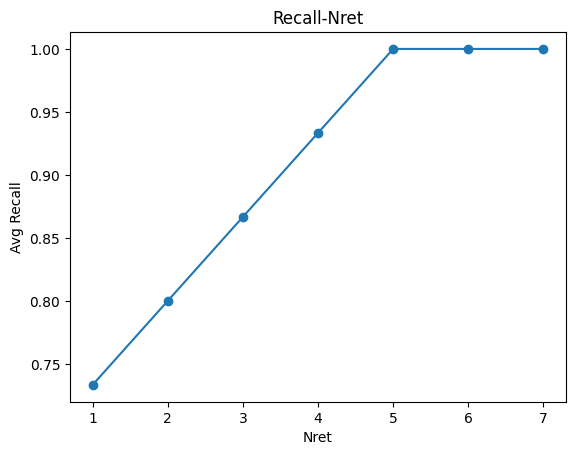

In [33]:
plt.plot(nret, avg_recall, marker='o')
plt.xlabel("Nret")
plt.ylabel("Avg Recall")
plt.title("Recall-Nret")
plt.show()